### Import Packages and Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas.api.types import CategoricalDtype

In [2]:
# make all columns scrollable
pd.set_option('display.max_columns', None)

### Read in Data

In [3]:
# convicted charges
convicted = pd.read_csv('Data/Gang Related Charges(Charges Convicted).csv', encoding='unicode_escape')
# all filed charges
filings = pd.read_csv('Data/Gang Related Charges(Filings).csv', encoding='unicode_escape')

/opt/Python/3.6.8/lib/python3.6/site-packages/IPython/core/interactiveshell.py:3058: DtypeWarning: Columns (85) have mixed types. Specify dtype option on import or set low_memory=False.
  interactivity=interactivity, compiler=compiler, result=result)


In [5]:
# county level overall population estimates
county_pop = pd.read_csv('Data/co-est2025-pop-21.csv')

# county level by race
county_race = pd.read_csv('Data/cc-est2024-alldata-21.csv')

### Initial Review

In [6]:
# look at convictions dataset
convicted.head(2)

,Case_ID,Region,County,Jurisdiction,Age_at_Case_Filing,Case_Category,Case_Filing_Date,Case_Disposition_Date,Charge_ID_Number,Charge Type,UOR_Code,Offense_Description,ASCF_Code,ASCF,AOC_Offense_Category_Code,AOC_Offense_Category,Charge_Level,Charge_Class,Charge_Filing_Date,Original_Plea,Final_Plea,Charge_Disposition_Date,Charge_Disposition,Charge_Disposition_Category,Trial_Type,Sentence_Date,SEN_FINE_SENT_AMT,SEN_FINE_PROB_AMT,SEN_FINE_SUSP_AMT,SEN_FINE_COND_AMT,SEN_COST_SENT_AMT,SEN_COST_PROB_AMT,SEN_COST_SUSP_AMT,SEN_COST_COND_AMT,SEN_CONCURRENT,SEN_CONSECUTIVE,SEN_JAIL,SEN_PRISON,SEN_JORP_SENT_YEARS,SEN_JORP_SENT_MONTHS,SEN_JORP_SENT_DAYS,SEN_JORP_SENT_HOURS,SEN_JORP_SUSP_YEARS,SEN_JORP_SUSP_MONTHS,SEN_JORP_SUSP_DAYS,SEN_JORP_SUSP_HOURS,SEN_JORP_COND_YEARS,SEN_JORP_COND_MONTHS,SEN_JORP_COND_DAYS,SEN_JORP_COND_HOURS,SEN_HOME_SENT_YEARS,SEN_HOME_SENT_MONTHS,SEN_HOME_SENT_DAYS,SEN_HOME_SENT_HOURS,SEN_HOME_SUSP_YEARS,SEN_HOME_SUSP_MONTHS,SEN_HOME_SUSP_DAYS,SEN_HOME_SUSP_HOURS,SEN_HOME_COND_YEARS,SEN_HOME_COND_MONTHS,SEN_HOME_COND_DAYS,SEN_HOME_COND_HOURS,SEN_PROB_SUPV_YEARS,SEN_PROB_SUPV_MONTHS,SEN_PROB_SUPV_DAYS,SEN_PROB_SUPV_HOURS,SEN_PROB_UNSP_YEARS,SEN_PROB_UNSP_MONTHS,SEN_PROB_UNSP_DAYS,SEN_PROB_UNSP_HOURS,SEN_LOCAL_PROBATION,SEN_STATE_PROBATION,SEN_COMM_SRVC_YEARS,SEN_COMM_SRVC_MONTHS,SEN_COMM_SRVC_DAYS,SEN_COMM_SRVC_HOURS,SEN_CRDT_TIME_YEARS,SEN_CRDT_TIME_MONTHS,SEN_CRDT_TIME_DAYS,SEN_CRDT_TIME_HOURS,SEN_LIFE_SENTENCE,SEN_DEATH_SENTENCE,SEN_A_D_E,SEN_UNDERGO_TREATMNT,SEN_MAKE_RESTITUTION,Judge_at_Sentence,Defendant_ID,Identification,Race,Ethnicity,Gender
0,360,Rural: Appalachian,ADAIR,Circuit Court,50,Circuit Criminal,3/12/2019,8/27/2019,1,Original Charge,239310,*OBS* TBUT OR DISP SHOPLIFTING $500 OR MORE BU...,0,Base,THF,Theft,Felony,D,3/12/2019,Not Guilty,Guilty,8/27/2019,GUILTY,Convicted,NO TRIAL,8/27/2019,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,629324,350,Criminal History Key,NaN,NaN,Female
1,361,Rural: Appalachian,ADAIR,Circuit Court,43,Circuit Criminal,3/12/2019,8/27/2019,1,Original Charge,239310,*OBS* TBUT OR DISP SHOPLIFTING $500 OR MORE BU...,0,Base,THF,Theft,Felony,D,3/12/2019,Not Guilty,Guilty,8/27/2019,GUILTY,Convicted,NO TRIAL,8/27/2019,NaN,NaN,NaN,NaN,165.0,NaN,NaN,NaN,0.0,0.0,0.0,1.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,629324,351,Criminal History Key,White,Non-Hispanic,Male


In [8]:
# look at filings dataset
filings.head(2)

,Case_ID,Region,County,Jurisdiction,Age_at_Case_Filing,Case_Category,Case_Filing_Date,Case_Disposition_Date,Charge_ID_Number,Charge Type,UOR_Code,Offense_Description,ASCF_Code,ASCF,AOC_Offense_Category_Code,AOC_Offense_Category,Charge_Level,Charge_Class,Charge_Filing_Date,Original_Plea,Final_Plea,Charge_Disposition_Date,Charge_Disposition,Charge_Disposition_Category,Trial_Type,Sentence_Date,SEN_FINE_SENT_AMT,SEN_FINE_PROB_AMT,SEN_FINE_SUSP_AMT,SEN_FINE_COND_AMT,SEN_COST_SENT_AMT,SEN_COST_PROB_AMT,SEN_COST_SUSP_AMT,SEN_COST_COND_AMT,SEN_CONCURRENT,SEN_CONSECUTIVE,SEN_JAIL,SEN_PRISON,SEN_JORP_SENT_YEARS,SEN_JORP_SENT_MONTHS,SEN_JORP_SENT_DAYS,SEN_JORP_SENT_HOURS,SEN_JORP_SUSP_YEARS,SEN_JORP_SUSP_MONTHS,SEN_JORP_SUSP_DAYS,SEN_JORP_SUSP_HOURS,SEN_JORP_COND_YEARS,SEN_JORP_COND_MONTHS,SEN_JORP_COND_DAYS,SEN_JORP_COND_HOURS,SEN_HOME_SENT_YEARS,SEN_HOME_SENT_MONTHS,SEN_HOME_SENT_DAYS,SEN_HOME_SENT_HOURS,SEN_HOME_SUSP_YEARS,SEN_HOME_SUSP_MONTHS,SEN_HOME_SUSP_DAYS,SEN_HOME_SUSP_HOURS,SEN_HOME_COND_YEARS,SEN_HOME_COND_MONTHS,SEN_HOME_COND_DAYS,SEN_HOME_COND_HOURS,SEN_PROB_SUPV_YEARS,SEN_PROB_SUPV_MONTHS,SEN_PROB_SUPV_DAYS,SEN_PROB_SUPV_HOURS,SEN_PROB_UNSP_YEARS,SEN_PROB_UNSP_MONTHS,SEN_PROB_UNSP_DAYS,SEN_PROB_UNSP_HOURS,SEN_LOCAL_PROBATION,SEN_STATE_PROBATION,SEN_COMM_SRVC_YEARS,SEN_COMM_SRVC_MONTHS,SEN_COMM_SRVC_DAYS,SEN_COMM_SRVC_HOURS,SEN_CRDT_TIME_YEARS,SEN_CRDT_TIME_MONTHS,SEN_CRDT_TIME_DAYS,SEN_CRDT_TIME_HOURS,SEN_LIFE_SENTENCE,SEN_DEATH_SENTENCE,SEN_A_D_E,SEN_UNDERGO_TREATMNT,SEN_MAKE_RESTITUTION,Judge_at_Sentence,Defendant_ID,Identification,Race,Ethnicity,Gender
0,193,Rural: Appalachian,ADAIR,Circuit Court,48,Circuit Criminal,3/12/2019,4/27/2021,2,Original Charge,234300,THEFT OF RETAIL MERCHANDISE FOR RESALE,0,Base,THF,Theft,Felony,C,3/12/2019,Not Guilty,Guilty,4/26/2021,GUILTY,Convicted,NO TRIAL,4/27/2021,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,5.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,629324,171,Criminal History Key,NaN,NaN,Male
1,194,Rural: Appalachian,ADAIR,Circuit Court,25,Circuit Criminal,3/12/2019,5/14/2019,1,Original Charge,239310,*OBS* TBUT OR DISP SHOPLIFTING $500 OR MORE BU...,0,Base,THF,Theft,Felony,D,3/12/2019,Not Guilty,Guilty,5/14/2019,GUILTY,Convicted,NO TRIAL,5/14/2019,NaN,NaN,NaN,NaN,165.0,NaN,NaN,NaN,1.0,1.0,0.0,1.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,629324,172,Criminal History Key,NaN,NaN,NaN


In [9]:
# number of unique cases filed
filings['Case_ID'].nunique()

2776

In [10]:
# number of unique defendants
filings['Defendant_ID'].nunique()

2034

In [12]:
# build unique identifier for each charge
convicted['Case_Charge_ID'] = convicted['Case_ID'].astype(str) + '_' + convicted['Charge_ID_Number'].astype(str)
filings['Case_Charge_ID'] = filings['Case_ID'].astype(str) + '_' + filings['Charge_ID_Number'].astype(str)

### Exploratory Analysis

#### Identify Gang-Related Charges

In [13]:
# convert UOR_Code to string for comparing
convicted['UOR_Code_Str'] = convicted['UOR_Code'].astype(str)
filings['UOR_Code_Str'] = filings['UOR_Code'].astype(str)

In [14]:
# base UOR codes for gang-related charges
krs_506_120_codes = ['23430', '23440', '60196', '70240']
krs_506_140_codes = ['12986', '12987', '12990', '12992', '12994', '12996']
gang_codes = krs_506_120_codes + krs_506_140_codes

In [15]:
# function to check if any of the gang codes are in the UOR_Code_Str
def check_gang_code(uor_code_str):
    for code in gang_codes:
        if code in uor_code_str:
            return True
    return False

In [16]:
# apply function to create flag for gang-related charges
convicted['Gang_Related'] = convicted['UOR_Code_Str'].apply(check_gang_code)
filings['Gang_Related'] = filings['UOR_Code_Str'].apply(check_gang_code)

In [17]:
# check that each case has at least one gang-related charge
print("Number of Filed Cases: " + str(filings['Case_ID'].nunique()))
print(filings.groupby('Case_ID')['Gang_Related'].any().value_counts(dropna=False))

Number of Filed Cases: 2776
True    2776
Name: Gang_Related, dtype: int64


In [18]:
# check whether every convicted cases has at lease one gang-related convicted charge
print("Number of Convicted Cases: " + str(convicted['Case_ID'].nunique()))
print(convicted.groupby('Case_ID')['Gang_Related'].any().value_counts(dropna=False))

Number of Convicted Cases: 1322
False    969
True     353
Name: Gang_Related, dtype: int64


It looks like there are many cases that initially have gang enhancement charges filed but are later dropped

- Example of case where gang-related charge was eventually dropped
- Note: Case_IDs and Defendant IDs are not consistent across datasets

In [19]:
filings[filings['Case_ID']==1254][['Case_ID', 'UOR_Code', 'Offense_Description', 'AOC_Offense_Category', 'Charge_Level', 'Charge_Disposition', 'Defendant_ID']]

,Case_ID,UOR_Code,Offense_Description,AOC_Offense_Category,Charge_Level,Charge_Disposition,Defendant_ID
15,1254,702400,ENGAGING IN ORGANIZED CRIME-CRIMINAL SYNDICATE,Organized Crime/Inchoate,Felony,DISMISSAL BY MOTION OF PROSECUTOR,974
16,1254,26680,PROBATION VIOLATION (FOR FELONY OFFENSE),Added Charges,Other,GUILTY,974
41,1254,420910,"TRAFF CONT SUB WITHIN 1,000 FEET OF SCHOOL",Drug Trafficking,Felony,GUILTY,974
43,1254,490310,PROMOTING CONTRABAND - 1ST DEGREE,Handgun,Felony,GUILTY,974


In [20]:
convicted[convicted['Case_ID']==880][['Case_ID', 'UOR_Code', 'Offense_Description', 'AOC_Offense_Category', 'Charge_Level', 'Charge_Disposition', 'Defendant_ID']]

,Case_ID,UOR_Code,Offense_Description,AOC_Offense_Category,Charge_Level,Charge_Disposition,Defendant_ID
9,880,420910,"TRAFF CONT SUB WITHIN 1,000 FEET OF SCHOOL",Drug Trafficking,Felony,GUILTY,858
10,880,490310,PROMOTING CONTRABAND - 1ST DEGREE,Handgun,Felony,GUILTY,858
11,880,26680,PROBATION VIOLATION (FOR FELONY OFFENSE),Added Charges,Other,GUILTY,858


#### Look at cases filed over time

In [21]:
# convert to datetime
filings['Case_Filing_Date'] = pd.to_datetime(filings['Case_Filing_Date'])
convicted['Case_Filing_Date'] = pd.to_datetime(convicted['Case_Filing_Date'])
convicted['Case_Disposition_Date'] = pd.to_datetime(convicted['Case_Disposition_Date'])

In [22]:
# extract filing month
filings['Case_Filing_Month'] = filings['Case_Filing_Date'].dt.to_period('M')

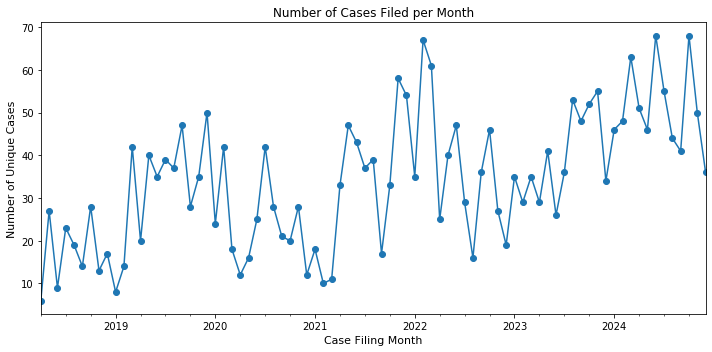

In [23]:
# plot the number of cases filed by month
cases_per_month = filings.groupby('Case_Filing_Month')['Case_ID'].nunique().sort_index()

fig, ax = plt.subplots(figsize=(10, 5))
cases_per_month.plot(kind='line', marker='o')

# set title and axes labels
plt.title('Number of Cases Filed per Month')
plt.xlabel('Case Filing Month',fontsize=11)
plt.ylabel('Number of Unique Cases',fontsize=11)

plt.tight_layout()
plt.show()

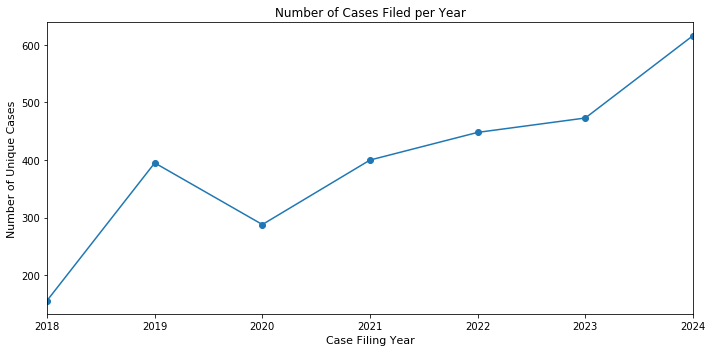

In [24]:
# extract filing year
filings['Case_Filing_Year'] = filings['Case_Filing_Date'].dt.to_period('Y')

# plot the number of cases filed by year
cases_per_year = filings.groupby('Case_Filing_Year')['Case_ID'].nunique().sort_index()

fig, ax = plt.subplots(figsize=(10, 5))
cases_per_year.plot(kind='line', marker='o')

# set title and axes labels
plt.title('Number of Cases Filed per Year')
plt.xlabel('Case Filing Year',fontsize=11)
plt.ylabel('Number of Unique Cases',fontsize=11)

plt.tight_layout()
plt.show()

### Geographic Analysis

#### Cases by county

In [26]:
# calculate number of cases per county
cases_per_county = filings.groupby('County')['Case_ID'].nunique().to_frame(name='# Unique Cases')

# calculate perc of all cases
cases_per_county['Percent of All Cases'] = (cases_per_county['# Unique Cases'] / filings['Case_ID'].nunique())

In [27]:
# calculate number of defendants per county
defendants_per_county = filings.groupby('County')['Defendant_ID'].nunique().to_frame(name='# Defendants')

# merge in with cases_per_county
cases_per_county = cases_per_county.merge(defendants_per_county, left_index=True, right_index=True)

In [28]:
# sort by number of cases
cases_per_county = cases_per_county.sort_values('# Unique Cases', ascending=False)

In [29]:
# look at counties with most cases
cases_per_county.head(10)

,# Unique Cases,Percent of All Cases,# Defendants
County,,,
JEFFERSON,373,0.134366,269
WARREN,157,0.056556,140
FAYETTE,147,0.052954,108
HARDIN,141,0.050793,99
MCCRACKEN,82,0.029539,54
KENTON,81,0.029179,67
WAYNE,77,0.027738,53
SHELBY,63,0.022695,36
BARREN,61,0.021974,42


#### Pull in Population Data

In [30]:
county_pop.head()

,Geographic Area,"April 1, 2020 Estimates Base",2020,2021,2022,2023,2024,2025
0,Kentucky,"4,506,287","4,508,271","4,508,348","4,521,238","4,549,953","4,584,046","4,606,864"
1,".Adair County, Kentucky","18,901","18,885","18,927","19,082","19,281","19,235","19,423"
2,".Allen County, Kentucky","20,579","20,573","20,833","21,249","21,821","22,095","22,536"
3,".Anderson County, Kentucky","23,880","23,902","24,106","24,298","24,636","24,958","25,225"
4,".Ballard County, Kentucky","7,730","7,712","7,687","7,629","7,605","7,608","7,594"


In [31]:
# remove top row
county_pop = county_pop.iloc[1:]

In [32]:
# extract county name
county_pop['County'] = county_pop['Geographic Area'].str.extract(r'.(.*?)County')

# capitalize county name to match
county_pop['County'] = county_pop['County'].str.upper()

# remove white space
county_pop['County'] = county_pop['County'].str.strip()

In [33]:
# convert population counts to integers
county_pop['2024'] = county_pop['2024'].str.replace(',', '').astype(int)

In [34]:
# keep county name and 2024 estimate only
county_pop = county_pop[['County', '2024']]

# make county name the index
county_pop = county_pop.set_index('County')

# rename population
county_pop = county_pop.rename(columns={'2024': 'General_Population'})

In [35]:
# merge in with cases_per_county
cases_per_county = cases_per_county.merge(county_pop, how='left', left_index=True, right_index=True)

In [36]:
# calculate # of defendants per 1,000
cases_per_county['Defendants_per_1000'] = cases_per_county['# Defendants'] / (cases_per_county['General_Population']/1000)

In [37]:
# counties with most cases
cases_per_county.head()

,# Unique Cases,Percent of All Cases,# Defendants,General_Population,Defendants_per_1000
County,,,,,
JEFFERSON,373,0.134366,269,794166,0.338720
WARREN,157,0.056556,140,146566,0.955201
FAYETTE,147,0.052954,108,327071,0.330204
HARDIN,141,0.050793,99,112644,0.878875
MCCRACKEN,82,0.029539,54,67732,0.797260


In [38]:
# counties with most defendants per 1000
cases_per_county.sort_values('Defendants_per_1000', ascending=False).head()

,# Unique Cases,Percent of All Cases,# Defendants,General_Population,Defendants_per_1000
County,,,,,
BALLARD,30,0.010807,22,7608,2.891693
WAYNE,77,0.027738,53,19563,2.709196
ELLIOTT,20,0.007205,19,7270,2.613480
BUTLER,32,0.011527,29,12480,2.323718
EDMONSON,32,0.011527,29,12662,2.290317


#### Conviction rates by county

In [39]:
# at case level, any convictions?
filings['any_convictions'] = filings['Charge_Disposition_Category'].eq('Convicted').groupby(filings['Case_ID']).transform('any')

# for every charge, is it gang related and convicted?
filings['Convicted_Gang_Charge'] = (filings['Gang_Related']==True) & (filings['Charge_Disposition_Category'].eq('Convicted'))

# at case level, any gang-related convictions?
filings['any_gang_convictions'] = (filings['Convicted_Gang_Charge'] == True).groupby(filings['Case_ID']).transform('any')

In [40]:
# remove undisposed cases and pending charges
filings_disposed = filings[(filings['Case_Disposition_Date'].notnull()) &
                          (filings['Charge_Disposition_Category'] != 'PENDING')]

In [41]:
# calculate number of cases per county
disposed_cases_per_county = filings_disposed.groupby('County')['Case_ID'].nunique().to_frame(name='# Disposed Cases')

# sort by number of cases
disposed_cases_per_county = disposed_cases_per_county.sort_values('# Disposed Cases', ascending=False)

In [42]:
# roll up to case level
filings_disposed = filings_disposed.sort_values('Case_ID')
filings_disposed_case = filings_disposed.groupby('Case_ID').first().reset_index()

In [43]:
# calculate percentage of cases with any convictions
conv_rate_by_county = filings_disposed_case.groupby('County')['any_convictions'].mean().to_frame(name='Any Charge Conviction Rate')

In [44]:
# calculate percentage of cases with any gang-related convictions
gang_conv_rate_by_county = filings_disposed_case.groupby('County')['any_gang_convictions'].mean().to_frame(name='Gang Charge Conviction Rate')

In [45]:
# merge in conv_rate_by_county
disposed_cases_per_county = disposed_cases_per_county.merge(conv_rate_by_county, left_index=True, right_index=True)

# merge in gang_conv_rate_by_county 
disposed_cases_per_county = disposed_cases_per_county.merge(gang_conv_rate_by_county, left_index=True, right_index=True)


In [47]:
# look at counties with most cases
disposed_cases_per_county.head(10)

,# Disposed Cases,Any Charge Conviction Rate,Gang Charge Conviction Rate
County,,,
JEFFERSON,342,0.327485,0.081871
WARREN,154,0.603896,0.103896
HARDIN,137,0.401460,0.211679
FAYETTE,122,0.516393,0.098361
KENTON,79,0.670886,0.050633
WAYNE,70,0.485714,0.285714
MCCRACKEN,69,0.391304,0.144928
BARREN,61,0.540984,0.377049
BULLITT,59,0.440678,0.016949


#### Statewide conviction rate

In [55]:
# conviction rate - % of cases with any conviction
print('Statewide Conviction Rate: ' + str(filings_disposed_case['any_convictions'].mean().round(3)))

# gang conviction rate - % of cases with any gang-related charge conviction
print('Statewide Gang Charge Conviction Rate: ' + str(filings_disposed_case['any_gang_convictions'].mean().round(3)))

Statewide Conviction Rate: 0.495
Statewide Gang Charge Conviction Rate: 0.128


In [49]:
# at charge level, what percentage of gang-related charges receive convictions?
filings_disposed[filings_disposed['Gang_Related']]['Convicted_Gang_Charge'].mean()

0.1180385288966725

#### Look at Any Conviction Rate vs Gang-Related Charge Conviction Rate

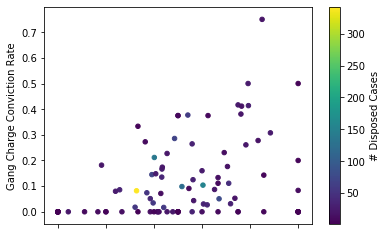

In [51]:
# plot conviction rate / gang charge conviction rate
disposed_cases_per_county.plot.scatter(x='Any Charge Conviction Rate', y='Gang Charge Conviction Rate', c='# Disposed Cases', cmap='viridis')

In [52]:
# look at counties with highest gang charge conviction rate
disposed_cases_per_county.sort_values('Gang Charge Conviction Rate', ascending=False).head(10)

,# Disposed Cases,Any Charge Conviction Rate,Gang Charge Conviction Rate
County,,,
ELLIOTT,20,0.850000,0.750000
ADAIR,4,1.000000,0.500000
GREENUP,24,0.791667,0.500000
MORGAN,24,0.750000,0.416667
CHRISTIAN,29,0.793103,0.413793
MONROE,17,0.764706,0.411765
PULASKI,21,0.761905,0.380952
BARREN,61,0.540984,0.377049
TRIGG,8,0.500000,0.375000


#### Look at counties with more than 30 disposed cases

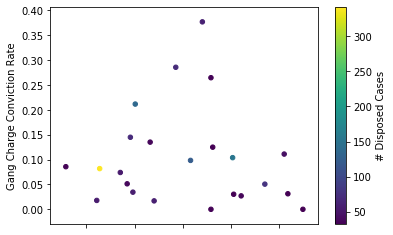

In [53]:
 disposed_cases_per_county[disposed_cases_per_county['# Disposed Cases']>30].plot.scatter(x='Any Charge Conviction Rate', 
                                                                      y='Gang Charge Conviction Rate', 
                                                                      c='# Disposed Cases', cmap='viridis')

In [54]:
 disposed_cases_per_county[disposed_cases_per_county['# Disposed Cases']>30].sort_values('Gang Charge Conviction Rate', 
                                                                     ascending=False).head(10)

,# Disposed Cases,Any Charge Conviction Rate,Gang Charge Conviction Rate
County,,,
BARREN,61,0.540984,0.377049
WAYNE,70,0.485714,0.285714
BOYD,34,0.558824,0.264706
HARDIN,137,0.401460,0.211679
MCCRACKEN,69,0.391304,0.144928
CAMPBELL,37,0.432432,0.135135
BOONE,32,0.562500,0.125000
SCOTT,45,0.711111,0.111111
WARREN,154,0.603896,0.103896


#### Look at by any conviction vs gang conviction rate by region

In [56]:
# look at breakdown of regions
filings['Region'].value_counts(normalize=True, dropna=False)

Louisville                         0.179492
Micropolitan: Western              0.149622
Metropolitan Region: Other         0.131115
Metropolitan Region: Louisville    0.114377
Rural: Appalachian                 0.104851
Rural: Western                     0.090222
Metropolitan Region: Lexington     0.084371
Micropolitan: Appalachian          0.050555
Metropolitan Region: Cincinnati    0.035109
Rural: North-Central               0.032728
Micropolitan: North-Central        0.027557
Name: Region, dtype: float64

In [57]:
# calculate number of cases per region
disposed_cases_per_region = filings_disposed.groupby('Region')['Case_ID'].nunique().to_frame(name='# Disposed Cases')

# sort by number of cases
disposed_cases_per_region = disposed_cases_per_region.sort_values('# Disposed Cases', ascending=False)

In [58]:
# calculate percentage of cases with any convictions
conv_rate_by_region = filings_disposed_case.groupby('Region')['any_convictions'].mean().to_frame(name='Any Charge Conviction Rate')

# calculate percentage of cases with gang-related convictions
gang_conv_rate_by_region = filings_disposed_case.groupby('Region')['any_gang_convictions'].mean().to_frame(name='Gang Charge Conviction Rate')

In [59]:
# merge in cases_per_county table
disposed_cases_per_region = disposed_cases_per_region.merge(conv_rate_by_region, left_index=True, right_index=True)

# merge in gang_conv_rate_by_county table
disposed_cases_per_region = disposed_cases_per_region.merge(gang_conv_rate_by_region, left_index=True, right_index=True)

In [60]:
disposed_cases_per_region.head(10)

,# Disposed Cases,Any Charge Conviction Rate,Gang Charge Conviction Rate
Region,,,
Metropolitan Region: Other,396,0.631313,0.169192
Louisville,342,0.327485,0.081871
Rural: Appalachian,341,0.560117,0.211144
Metropolitan Region: Louisville,310,0.403226,0.116129
Micropolitan: Western,284,0.450704,0.172535
Rural: Western,215,0.558140,0.041860
Micropolitan: Appalachian,196,0.357143,0.076531
Metropolitan Region: Lexington,186,0.564516,0.096774
Metropolitan Region: Cincinnati,158,0.563291,0.082278


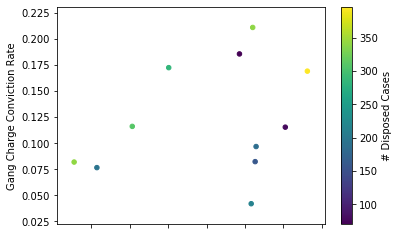

In [61]:
# plot conviction rate / gang charge conviction rate
disposed_cases_per_region.plot.scatter(x='Any Charge Conviction Rate', y='Gang Charge Conviction Rate', c='# Disposed Cases', cmap='viridis')

#### Demographics

Breakdown of demographics for filings vs convictions

According to a KYCounts Report: https://www.kycourts.gov/AOC/Information-and-Technology/Analytics/Custom%20Reports/PFO_Charges_in_Circuit_Criminal_Cases_Filed_since_1-1-2017_with_Race_and_Ethnicity.pdf

General KY Population (2019 Census Pop Estimate)
- Black: 8.0%
- White: 85.6%
- Hispanic: 3.3%
- Other: 3.1% 

All Circuit Criminal Cases Filed (2017-2022)
- Black: 15.3%
- White: 65.9%
- Hispanic: 1.3%
- Other: 0.2%
- Unknown: 17.2%

In [62]:
# roll up all charges to case level
filings_case = filings.groupby('Case_ID').first().reset_index()

In [63]:
# fill in missing race
filings_case['Race'] = filings_case['Race'].fillna('Unknown')
filings_disposed_case['Race'] = filings_disposed_case['Race'].fillna('Unknown')

In [64]:
# look at race breakdown by county
filings_race = pd.crosstab(
    index=filings_case['County'], 
    columns=filings_case['Race'],
    margins=True,
    margins_name = 'Total',
    normalize='index')

filings_race

Race,Asian,Black,Indian,Unknown,White
County,,,,,
ADAIR,0.000000,0.000000,0.000000,0.750000,0.250000
ALLEN,0.000000,0.000000,0.000000,0.000000,1.000000
ANDERSON,0.000000,0.000000,0.000000,0.000000,1.000000
BALLARD,0.000000,0.366667,0.000000,0.000000,0.633333
BARREN,0.000000,0.393443,0.000000,0.049180,0.557377
...,...,...,...,...,...
WEBSTER,0.000000,0.130435,0.000000,0.130435,0.739130
WHITLEY,0.000000,0.000000,0.000000,0.600000,0.400000
WOLFE,0.000000,0.000000,0.000000,0.111111,0.888889


#### Pull in Population Data

In [67]:
county_race.head()

,SUMLEV,STATE,COUNTY,STNAME,CTYNAME,YEAR,AGEGRP,TOT_POP,TOT_MALE,TOT_FEMALE,WA_MALE,WA_FEMALE,BA_MALE,BA_FEMALE,IA_MALE,IA_FEMALE,AA_MALE,AA_FEMALE,NA_MALE,NA_FEMALE,TOM_MALE,TOM_FEMALE,WAC_MALE,WAC_FEMALE,BAC_MALE,BAC_FEMALE,IAC_MALE,IAC_FEMALE,AAC_MALE,AAC_FEMALE,NAC_MALE,NAC_FEMALE,NH_MALE,NH_FEMALE,NHWA_MALE,NHWA_FEMALE,NHBA_MALE,NHBA_FEMALE,NHIA_MALE,NHIA_FEMALE,NHAA_MALE,NHAA_FEMALE,NHNA_MALE,NHNA_FEMALE,NHTOM_MALE,NHTOM_FEMALE,NHWAC_MALE,NHWAC_FEMALE,NHBAC_MALE,NHBAC_FEMALE,NHIAC_MALE,NHIAC_FEMALE,NHAAC_MALE,NHAAC_FEMALE,NHNAC_MALE,NHNAC_FEMALE,H_MALE,H_FEMALE,HWA_MALE,HWA_FEMALE,HBA_MALE,HBA_FEMALE,HIA_MALE,HIA_FEMALE,HAA_MALE,HAA_FEMALE,HNA_MALE,HNA_FEMALE,HTOM_MALE,HTOM_FEMALE,HWAC_MALE,HWAC_FEMALE,HBAC_MALE,HBAC_FEMALE,HIAC_MALE,HIAC_FEMALE,HAAC_MALE,HAAC_FEMALE,HNAC_MALE,HNAC_FEMALE,White_Total,Black_Total,Indian_Total,Asian_Total,Other_Total
95,50,21,1,Kentucky,Adair County,6,0,19239,9595,9644,8951,9137,320,185,42,45,71,71,5,8,206,198,9153,9328,443,315,115,109,86,84,7,14,9170,9334,8598,8873,301,178,32,37,65,65,1,2,173,179,8770,9046,406,298,89,90,77,77,3,5,425,310,353,264,19,7,10,8,6,6,4,6,33,19,383,282,37,17,26,19,9,7,4,9,18088,505,87,142,417
209,50,21,3,Kentucky,Allen County,6,0,22037,10925,11112,10413,10705,227,135,38,38,38,48,5,3,204,183,10612,10882,335,234,119,108,56,69,9,9,10540,10803,10101,10428,186,124,29,30,36,45,3,3,185,173,10281,10595,288,216,99,96,52,66,7,9,385,309,312,277,41,11,9,8,2,3,2,0,19,10,331,287,47,18,20,12,4,3,2,0,21118,362,76,86,395
323,50,21,5,Kentucky,Anderson County,6,0,24883,12366,12517,11659,11833,326,268,53,36,89,100,9,5,230,275,11882,12097,455,417,124,125,123,145,15,15,11901,12213,11269,11574,305,257,27,25,81,96,3,3,216,258,11478,11823,428,400,91,103,114,139,9,12,465,304,390,259,21,11,26,11,8,4,6,2,14,17,404,274,27,17,33,22,9,6,6,3,23492,594,89,189,519
437,50,21,7,Kentucky,Ballard County,6,0,7626,3808,3818,3498,3548,168,131,9,16,20,23,2,2,111,98,3606,3646,233,190,44,47,34,31,3,5,3734,3757,3442,3512,159,122,7,10,20,20,2,2,104,91,3544,3603,222,178,38,39,33,26,2,5,74,61,56,36,9,9,2,6,0,3,0,0,7,7,62,43,11,12,6,8,1,5,1,0,7046,299,25,43,213
551,50,21,9,Kentucky,Barren County,6,0,45609,22104,23505,20226,21653,947,918,120,86,260,277,83,59,468,512,20677,22152,1239,1257,265,215,303,339,97,67,20985,22448,19359,20809,912,853,54,48,235,246,36,30,389,462,19735,21260,1166,1166,161,159,271,299,46,38,1119,1057,867,844,35,65,66,38,25,31,47,29,79,50,942,892,73,91,104,56,32,40,51,29,41879,1865,206,537,1122


In [65]:
# only keep rows for all age groups
county_race = county_race[county_race['AGEGRP']==0]

# only keep rows for 2024
county_race = county_race[county_race['YEAR']==6]

In [66]:
# calculate demographics counts
county_race['White_Total'] = county_race['WA_MALE'] + county_race['WA_FEMALE']
county_race['Black_Total'] = county_race['BA_MALE'] + county_race['BA_FEMALE']
county_race['Indian_Total'] = county_race['IA_MALE'] + county_race['IA_FEMALE']
county_race['Asian_Total'] = county_race['AA_MALE'] + county_race['AA_FEMALE']
# native hawaiian and multiracial
county_race['Other_Total'] = county_race['NA_MALE'] + county_race['NA_FEMALE'] + county_race['TOM_MALE'] + county_race['TOM_FEMALE']

In [68]:
dem_cols = ['White_Total', 'Black_Total', 'Indian_Total', 'Asian_Total', 'Other_Total']

for c in dem_cols:
    # calculate race percentages
    perc_col = str.split(c,'_')[0] + '_General'
    county_race[perc_col] = county_race[c] / county_race['TOT_POP']

In [69]:
# add total row
county_race['TOT_POP'].sum()

4588372

In [70]:
# statewide total
county_pop_total = county_race['TOT_POP'].sum()

# initiate row for total percentages
total_row = pd.DataFrame({'County': ['Total']})

# add statewide percentages
total_row['White_General'] = county_race['White_Total'].sum() / county_pop_total
total_row['Black_General'] = county_race['Black_Total'].sum() / county_pop_total
total_row['Indian_General'] = county_race['Indian_Total'].sum() / county_pop_total
total_row['Asian_General'] = county_race['Asian_Total'].sum() / county_pop_total
total_row['Other_General'] = county_race['Other_Total'].sum() / county_pop_total

In [71]:
# limit columns
county_race = county_race[['CTYNAME', 'White_General', 'Black_General', 'Indian_General', 'Asian_General', 'Other_General']]

# rename county col
county_race = county_race.rename(columns={'CTYNAME': 'County'})

In [72]:
# clean county column
county_race['County'] = county_race['County'].str.split().str[0]
county_race['County'] = county_race['County'].str.upper()

In [73]:
# add total row
county_race = pd.concat([county_race, total_row], ignore_index=True)

In [75]:
# make county the index
county_race = county_race.set_index('County')

In [76]:
county_race

,White_General,Black_General,Indian_General,Asian_General,Other_General
County,,,,,
ADAIR,0.940174,0.026249,0.004522,0.007381,0.021675
ALLEN,0.958297,0.016427,0.003449,0.003903,0.017924
ANDERSON,0.944098,0.023872,0.003577,0.007596,0.020858
BALLARD,0.923944,0.039208,0.003278,0.005639,0.027931
BARREN,0.918218,0.040891,0.004517,0.011774,0.024600
...,...,...,...,...,...
WEBSTER,0.908278,0.040688,0.009647,0.007780,0.033608
WHITLEY,0.963232,0.011468,0.003304,0.005882,0.016115
WOLFE,0.977216,0.005185,0.005028,0.002200,0.010371


In [77]:
# merge general population race data with charge race data
filings_race = filings_race.merge(county_race, how='left', left_index=True, right_index=True)

In [78]:
filings_race.head()

,Asian,Black,Indian,Unknown,White,White_General,Black_General,Indian_General,Asian_General,Other_General
County,,,,,,,,,,
ADAIR,0.0,0.000000,0.0,0.75000,0.250000,0.940174,0.026249,0.004522,0.007381,0.021675
ALLEN,0.0,0.000000,0.0,0.00000,1.000000,0.958297,0.016427,0.003449,0.003903,0.017924
ANDERSON,0.0,0.000000,0.0,0.00000,1.000000,0.944098,0.023872,0.003577,0.007596,0.020858
BALLARD,0.0,0.366667,0.0,0.00000,0.633333,0.923944,0.039208,0.003278,0.005639,0.027931
BARREN,0.0,0.393443,0.0,0.04918,0.557377,0.918218,0.040891,0.004517,0.011774,0.024600


#### Race Breakdown for Convicted Cases

In [79]:
# roll up to case level
convicted_case = convicted.groupby('Case_ID').first().reset_index()

In [80]:
# fill in missing race
convicted_case['Race'] = convicted_case['Race'].fillna('Unknown')

In [81]:
convicted_race = pd.crosstab(
    index=convicted_case['County'], 
    columns=convicted_case['Race'],
    margins=True,
    margins_name = 'Total',
    normalize='index')

convicted_race

Race,Asian,Black,Indian,Unknown,White
County,,,,,
ADAIR,0.000000,0.000000,0.000000,0.750000,0.250000
ALLEN,0.000000,0.000000,0.000000,0.000000,1.000000
BALLARD,0.000000,0.076923,0.000000,0.000000,0.923077
BARREN,0.000000,0.406250,0.000000,0.062500,0.531250
BELL,0.000000,0.000000,0.000000,0.000000,1.000000
...,...,...,...,...,...
WEBSTER,0.000000,0.000000,0.000000,0.333333,0.666667
WHITLEY,0.000000,0.000000,0.000000,0.814815,0.185185
WOLFE,0.000000,0.000000,0.000000,0.000000,1.000000


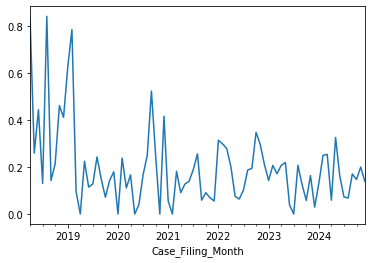

In [82]:
# look into unknown race usage
(filings_case['Race']=='Unknown').groupby(filings_case['Case_Filing_Month']).mean().plot()

In [83]:
# geography with highest proportion of unknown race
filings_race_merge = filings_race.merge(cases_per_county, left_index=True, right_index=True)

# counties with largest share of missing race info
filings_race_merge.sort_values('Unknown', ascending=False).head(10)

,Asian,Black,Indian,Unknown,White,White_General,Black_General,Indian_General,Asian_General,Other_General,# Unique Cases,Percent of All Cases,# Defendants,General_Population,Defendants_per_1000
County,,,,,,,,,,,,,,,
TAYLOR,0.0,0.000000,0.0,1.000000,0.000000,0.906673,0.054683,0.002387,0.010519,0.025738,13,0.004683,13,26811,0.484876
GREEN,0.0,0.000000,0.0,1.000000,0.000000,0.950744,0.019044,0.004761,0.003463,0.021988,3,0.001081,3,11548,0.259785
LAUREL,0.0,0.000000,0.0,0.956522,0.043478,0.964343,0.010071,0.003915,0.007577,0.014096,23,0.008285,18,63244,0.284612
PERRY,0.0,0.000000,0.0,0.916667,0.083333,0.958488,0.016829,0.002431,0.008676,0.013576,12,0.004323,12,26805,0.447678
ELLIOTT,0.0,0.000000,0.0,0.850000,0.150000,0.932672,0.045849,0.004268,0.002203,0.015008,20,0.007205,19,7270,2.613480
MUHLENBERG,0.0,0.055556,0.0,0.777778,0.166667,0.938942,0.038083,0.002950,0.003605,0.016420,18,0.006484,18,30572,0.588774
FLOYD,0.0,0.000000,0.0,0.769231,0.230769,0.977354,0.008051,0.001709,0.003909,0.008977,26,0.009366,18,34630,0.519781
PULASKI,0.0,0.095238,0.0,0.761905,0.142857,0.956689,0.013644,0.003920,0.009709,0.016038,21,0.007565,20,66959,0.298690
CARTER,0.0,0.000000,0.0,0.750000,0.250000,0.974404,0.007970,0.003104,0.003334,0.011189,28,0.010086,25,26195,0.954381


In [84]:
# for counties with at least 30 cases, look at counties with largest share of missing race info
filings_race_merge[filings_race_merge['# Unique Cases']>30].sort_values('Unknown', ascending=False).head(10)

,Asian,Black,Indian,Unknown,White,White_General,Black_General,Indian_General,Asian_General,Other_General,# Unique Cases,Percent of All Cases,# Defendants,General_Population,Defendants_per_1000
County,,,,,,,,,,,,,,,
SIMPSON,0.000000,0.212121,0.0,0.515152,0.272727,0.868845,0.091007,0.004373,0.009730,0.026044,33,0.011888,29,20418,1.420315
BOYD,0.000000,0.138889,0.0,0.472222,0.388889,0.939071,0.030663,0.005421,0.006593,0.018251,36,0.012968,28,47948,0.583966
LAWRENCE,0.000000,0.066667,0.0,0.422222,0.511111,0.971072,0.006140,0.001772,0.003228,0.017787,45,0.016210,34,15825,2.148499
BUTLER,0.000000,0.000000,0.0,0.281250,0.718750,0.956816,0.010358,0.011394,0.005737,0.015696,32,0.011527,29,12480,2.323718
KNOX,0.000000,0.087719,0.0,0.245614,0.666667,0.962538,0.013622,0.003237,0.005462,0.015140,57,0.020533,45,29652,1.517604
KENTON,0.000000,0.320988,0.0,0.197531,0.481481,0.898194,0.054117,0.004003,0.016379,0.027307,81,0.029179,67,174441,0.384084
HARDIN,0.028369,0.581560,0.0,0.191489,0.198582,0.797618,0.123589,0.005672,0.024569,0.048553,141,0.050793,99,112644,0.878875
WARREN,0.050955,0.401274,0.0,0.184713,0.363057,0.788158,0.105782,0.003596,0.065420,0.037043,157,0.056556,140,146566,0.955201
CALLOWAY,0.000000,0.589744,0.0,0.179487,0.230769,0.907967,0.045080,0.004387,0.020141,0.022425,39,0.014049,20,38902,0.514112


#### Disparities in Sentencing Outcomes within Filings

Of disposed cases with gang-related charges, what percentage of the cases recieved convictions on the any charges? How does that differ by race?

In [85]:
# % of cases with any convictions by race
filings_disposed_case.groupby('Race')['any_convictions'].mean().to_frame(name='Any Charge Conviction Rate')

,Any Charge Conviction Rate
Race,
Asian,0.333333
Black,0.397558
Indian,0.500000
Unknown,0.648889
White,0.499633


Of disposed cases with gang-related charges, what percentage of the cases recieved convictions on gang-related charges? How does that differ by race?

In [86]:
# % of cases with any gang-related convictions by race
filings_disposed_case.groupby('Race')['any_gang_convictions'].mean().to_frame(name='Any Gang Charge Conviction Rate')

,Any Gang Charge Conviction Rate
Race,
Asian,0.041667
Black,0.116689
Indian,0.000000
Unknown,0.173333
White,0.120323


#### Charges

What gang-related charges are most common?

In [87]:
filings[filings['Gang_Related']]['Offense_Description'].value_counts(normalize=True)

ENGAGING IN ORGANIZED CRIME-CRIMINAL SYNDICATE               0.802679
COMP ENGAGING IN ORGANIZED CRIME-CRIMINAL SYNDICATE          0.057171
THEFT OF RETAIL MERCHANDISE FOR RESALE                       0.052270
FACL ENGAGING IN ORGANIZED CRIME-CRIMINAL SYNDICATE          0.028422
ATT ENGAGING IN ORGANIZED CRIME-CRIMINAL SYNDICATE           0.011434
COMP THEFT OF RETAIL MERCHANDISE FOR RESALE                  0.011434
CONS THEFT OF RETAIL MERCHANDISE FOR RESALE                  0.009147
ACQUISITION OF RETAIL MERCHANDISE FOR RESALE                 0.007187
CONS ENGAGING IN ORGANIZED CRIME-CRIMINAL SYNDICATE          0.006207
ATT THEFT OF RETAIL MERCHANDISE FOR RESALE                   0.004574
*OBS* ENGAGING IN ORGANIZED CRIME/CRIMINAL SYNDICATE         0.003267
CRIMINAL GANG RECRUITMENT - 1ST DEGREE - 1ST OFFENSE         0.002614
CRIMINAL GANG RECRUITMENT - 3RD DEGREE - 1ST OFFENSE         0.001633
FACL ACQUISITION OF RETAIL MERCHANDISE FOR RESALE            0.000653
COMP ACQUISITION OF 

For each gang-related offense, what percentage are convicted?

In [88]:
# percentage of charges that are convicted, by offense
gang_charges = filings_disposed[filings_disposed['Gang_Related']]
gang_charges.groupby('Offense_Description')['Charge_Disposition_Category'].apply(lambda x: (x == 'Convicted').mean())

Offense_Description
*OBS* ENGAGING IN ORGANIZED CRIME/CRIMINAL SYNDICATE         0.100000
*OBS* FACL ENGAGING IN ORGANIZED CRIME/CRIMINAL SYNDICATE    1.000000
ACQUISITION OF RETAIL MERCHANDISE FOR RESALE                 0.136364
ATT ENGAGING IN ORGANIZED CRIME-CRIMINAL SYNDICATE           0.588235
ATT THEFT OF RETAIL MERCHANDISE FOR RESALE                   0.642857
COMP ACQUISITION OF RETAIL MERCHANDISE FOR RESALE            1.000000
COMP ENGAGING IN ORGANIZED CRIME-CRIMINAL SYNDICATE          0.069182
COMP THEFT OF RETAIL MERCHANDISE FOR RESALE                  0.406250
CONS ENGAGING IN ORGANIZED CRIME-CRIMINAL SYNDICATE          0.222222
CONS THEFT OF RETAIL MERCHANDISE FOR RESALE                  0.000000
CRIMINAL GANG RECRUITMENT - 1ST DEGREE - 1ST OFFENSE         1.000000
CRIMINAL GANG RECRUITMENT - 2ND DEGREE - 1ST OFFENSE         0.000000
CRIMINAL GANG RECRUITMENT - 3RD DEGREE - 1ST OFFENSE         0.400000
ENGAGING IN ORGANIZED CRIME-CRIMINAL SYNDICATE               0.072839


#### Charge Level

In [89]:
# strip whitespace from charge class
filings['Charge_Class'] = filings['Charge_Class'].str.strip()

In [90]:
# make level + class field
filings['Charge_Level_Class'] = filings['Charge_Level'] + '_' + filings['Charge_Class']

In [91]:
# overall most common charge level
filings['Charge_Level_Class'].value_counts(normalize=True)

Felony_D             0.340886
Felony_B             0.211472
Felony_C             0.165476
Misdemeanor_A        0.112268
Misdemeanor_B        0.086344
Other_X              0.038103
Felony_X             0.031979
Violation_X          0.008097
Felony_A             0.004491
Local Ordinance_X    0.000408
?_X                  0.000272
Misdemeanor_X        0.000204
Name: Charge_Level_Class, dtype: float64

In [92]:
# most common non-gang charge levels
filings[filings['Gang_Related']==False]['Charge_Level_Class'].value_counts(normalize=True)

Felony_D             0.422912
Felony_C             0.184857
Misdemeanor_A        0.137590
Misdemeanor_B        0.109058
Other_X              0.048127
Felony_X             0.040392
Felony_B             0.040048
Violation_X          0.010227
Felony_A             0.005672
Local Ordinance_X    0.000516
?_X                  0.000344
Misdemeanor_X        0.000258
Name: Charge_Level_Class, dtype: float64

#### Highest Charge per Case

In [93]:
# make ordered category
charge_order = CategoricalDtype(categories=['?_X', 'Local Ordinance_X','Other_X', 'Violation_X',
                                            'Misdemeanor_X', 'Misdemeanor_B', 'Misdemeanor_A', 
                                            'Felony_X', 'Felony_D', 'Felony_C', 'Felony_B', 'Felony_A'], ordered=True)

# apply order
filings['Charge_Level_Class'] = filings['Charge_Level_Class'].astype(charge_order)

# convert to code
filings['Charge_Level_Code'] = filings['Charge_Level_Class'].cat.codes

In [95]:
# highest charge indicator
filings['is_highest_charge'] = filings['Charge_Level_Code'] == filings.groupby('Case_ID')['Charge_Level_Code'].transform('max')

#### For non-gang related charges, get highest charge

In [96]:
# filter for non-gang related charges
filings_nongang = filings[filings['Gang_Related']==False].copy()

In [97]:
# remake highest charge indicator
filings_nongang['is_highest_charge'] = filings_nongang['Charge_Level_Code'] == filings_nongang.groupby('Case_ID')['Charge_Level_Code'].transform('max')

In [98]:
# look at charge level/class among highest non-gang charges
filings_nongang[filings_nongang['is_highest_charge']]['Charge_Level_Class'].value_counts(normalize=True)

Felony_D             0.448461
Felony_C             0.366688
Felony_B             0.089520
Misdemeanor_A        0.040456
Felony_X             0.014633
Felony_A             0.014203
Misdemeanor_B        0.014203
Other_X              0.010329
?_X                  0.000861
Violation_X          0.000646
Misdemeanor_X        0.000000
Local Ordinance_X    0.000000
Name: Charge_Level_Class, dtype: float64

Are gang allegations concentrated among violent offenses?

In [99]:
# look for any convicted class A felonies 
filings_disposed[(filings_disposed['Charge_Level']=='Felony') & ((filings_disposed['Charge_Class']=='A ')) & 
                 ((filings_disposed['Charge_Disposition_Category']=='Convicted'))]

,Case_ID,Region,County,Jurisdiction,Age_at_Case_Filing,Case_Category,Case_Filing_Date,Case_Disposition_Date,Charge_ID_Number,Charge Type,UOR_Code,Offense_Description,ASCF_Code,ASCF,AOC_Offense_Category_Code,AOC_Offense_Category,Charge_Level,Charge_Class,Charge_Filing_Date,Original_Plea,Final_Plea,Charge_Disposition_Date,Charge_Disposition,Charge_Disposition_Category,Trial_Type,Sentence_Date,SEN_FINE_SENT_AMT,SEN_FINE_PROB_AMT,SEN_FINE_SUSP_AMT,SEN_FINE_COND_AMT,SEN_COST_SENT_AMT,SEN_COST_PROB_AMT,SEN_COST_SUSP_AMT,SEN_COST_COND_AMT,SEN_CONCURRENT,SEN_CONSECUTIVE,SEN_JAIL,SEN_PRISON,SEN_JORP_SENT_YEARS,SEN_JORP_SENT_MONTHS,SEN_JORP_SENT_DAYS,SEN_JORP_SENT_HOURS,SEN_JORP_SUSP_YEARS,SEN_JORP_SUSP_MONTHS,SEN_JORP_SUSP_DAYS,SEN_JORP_SUSP_HOURS,SEN_JORP_COND_YEARS,SEN_JORP_COND_MONTHS,SEN_JORP_COND_DAYS,SEN_JORP_COND_HOURS,SEN_HOME_SENT_YEARS,SEN_HOME_SENT_MONTHS,SEN_HOME_SENT_DAYS,SEN_HOME_SENT_HOURS,SEN_HOME_SUSP_YEARS,SEN_HOME_SUSP_MONTHS,SEN_HOME_SUSP_DAYS,SEN_HOME_SUSP_HOURS,SEN_HOME_COND_YEARS,SEN_HOME_COND_MONTHS,SEN_HOME_COND_DAYS,SEN_HOME_COND_HOURS,SEN_PROB_SUPV_YEARS,SEN_PROB_SUPV_MONTHS,SEN_PROB_SUPV_DAYS,SEN_PROB_SUPV_HOURS,SEN_PROB_UNSP_YEARS,SEN_PROB_UNSP_MONTHS,SEN_PROB_UNSP_DAYS,SEN_PROB_UNSP_HOURS,SEN_LOCAL_PROBATION,SEN_STATE_PROBATION,SEN_COMM_SRVC_YEARS,SEN_COMM_SRVC_MONTHS,SEN_COMM_SRVC_DAYS,SEN_COMM_SRVC_HOURS,SEN_CRDT_TIME_YEARS,SEN_CRDT_TIME_MONTHS,SEN_CRDT_TIME_DAYS,SEN_CRDT_TIME_HOURS,SEN_LIFE_SENTENCE,SEN_DEATH_SENTENCE,SEN_A_D_E,SEN_UNDERGO_TREATMNT,SEN_MAKE_RESTITUTION,Judge_at_Sentence,Defendant_ID,Identification,Race,Ethnicity,Gender,Case_Charge_ID,UOR_Code_Str,Gang_Related,Case_Filing_Month,Case_Filing_Year,any_convictions,Convicted_Gang_Charge,any_gang_convictions
9488,259,Rural: Western,LOGAN,Circuit Court,60,Circuit Criminal,2019-05-17,1/27/2023,8,Original Charge,91505,COMP MURDER,5,Complicity,MDR,Murder,Felony,A,7/29/2022,Not Guilty,Not Guilty,1/27/2023,GUILTY,Convicted,JURY TRIAL,1/27/2023,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,607395,223,Criminal History Key,White,Non-Hispanic,Male,259_8,91505,False,2019-05,2019,True,False,True


In [100]:
# look at breakdown of offenses among highest charges
filings_nongang[filings_nongang['is_highest_charge']]['AOC_Offense_Category'].value_counts(normalize=True)

Theft                                            0.354422
Drug Trafficking                                 0.235206
Forgery                                          0.089090
Burglary                                         0.046482
Handgun                                          0.035722
Fraud                                            0.027975
Drug Possession                                  0.020658
Theft of Gun                                     0.020443
Assault Related Offenses                         0.016570
Computer Related Offenses                        0.013988
Interfering Judicial Admin.                      0.012696
Robbery                                          0.011836
Persistent Felony Offenses                       0.011405
Drug Other                                       0.011190
Impersonating                                    0.010975
Theft - Auto                                     0.010329
Added Charges                                    0.010114
Criminal Misch

#### Age

In [102]:
# look at records  for defendants under 18
filings[filings['Age_at_Case_Filing']<18]['Age_at_Case_Filing'].value_counts()

17    71
0     66
Name: Age_at_Case_Filing, dtype: int64

In [103]:
# function for age category
def get_age_category(age):
    if age == 0: 
        return "Unknown"
    elif age < 18:
        return "Minor"
    elif age < 26:
        return "18-25"
    elif age < 40:
        return "26-39"
    elif age < 50:
        return "40-49"
    else: 
        return "50+"

In [104]:
# apply function to get age category
filings['age_category'] = filings['Age_at_Case_Filing'].apply(get_age_category)

In [105]:
# roll up to case level
filings_case = filings.groupby('Case_ID').first().reset_index()

In [107]:
# see age breakdown at case level
filings_case['age_category'].value_counts()

26-39      1124
18-25       850
40-49       463
50+         314
Unknown      21
Minor         4
Name: age_category, dtype: int64

#### Pleas

In [108]:
# look at breakdown of original plea
filings_disposed['Original_Plea'].value_counts(normalize=True)

Unknown       0.660848
Not Guilty    0.296255
Guilty        0.042898
Name: Original_Plea, dtype: float64

In [109]:
# look at breakdown of final plea
filings_disposed['Final_Plea'].value_counts(normalize=True)

Unknown       0.661146
Guilty        0.205163
Not Guilty    0.133691
Name: Final_Plea, dtype: float64

Check difference in pleas for gang vs nongang related charges 

In [112]:
# non-gang charge pleas
filings_disposed[filings_disposed['Gang_Related']==False]['Original_Plea'].value_counts(normalize=True)

Unknown       0.642999
Not Guilty    0.308276
Guilty        0.048725
Name: Original_Plea, dtype: float64

In [113]:
# gang charge pleas
filings_disposed[filings_disposed['Gang_Related']==True]['Original_Plea'].value_counts(normalize=True)

Unknown       0.726795
Not Guilty    0.251839
Guilty        0.021366
Name: Original_Plea, dtype: float64

#### Sentences

Among convicted, what percentage are sentenced to incarceration?

In [114]:
# indicator for incarceration sentence
filings_disposed['sen_incarceration'] = filings_disposed[['SEN_JAIL', 'SEN_PRISON', 'SEN_LIFE_SENTENCE']].eq(1).any(axis=1)

In [115]:
# at case level, determine if incarceration sentence
filings_disposed['any_sen_incarceration'] = (filings_disposed['sen_incarceration'] == True).groupby(filings_disposed['Case_ID']).transform('any')

In [116]:
# for cases with convictions
filings_convicted = filings_disposed[filings_disposed['any_convictions']==True].copy()

In [119]:
# percent of cases with any convictions that are sentenced to incarceration
filings_convicted['any_sen_incarceration'].mean()

0.9889017937798426

In [118]:
# percent of cases with convicted gang charges that are sentenced to incarceration
filings_convicted[filings_convicted['any_gang_convictions']==True]['any_sen_incarceration'].mean()

0.9983561643835617

#### Judges

In [121]:
# breakdown of judges
filings_convicted['Judge_at_Sentence'].value_counts(dropna=False, normalize=True)

NaN         0.529875
643358      0.024003
642445      0.022325
608217.0    0.014195
630305      0.012776
              ...   
730075.0    0.000129
714008.0    0.000129
650478.0    0.000129
725010      0.000129
730054      0.000129
Name: Judge_at_Sentence, Length: 202, dtype: float64